In [13]:
import lsdb
from dask.distributed import Client
import numpy as np
import matplotlib.pyplot as plt


import logging

In [14]:
client=Client(n_workers=4, memory_limit="8GB", threads_per_worker=1, silence_logs=logging.ERROR)
client

/astro/users/brantd/.conda/envs/lsdb_operations/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41409 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:41409/status,
Dashboard: http://127.0.0.1:41409/status,Workers: 4
Total threads: 4,Total memory: 29.80 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45749,Workers: 0
Dashboard: http://127.0.0.1:41409/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44581,Total threads: 1
Dashboard: http://127.0.0.1:34913/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:35623,


## 1. Generate Comparison Catalog

In [20]:
dp2_fitted = lsdb.open_catalog("../dp2_fitted_medium")
li_gaia = lsdb.open_catalog("/astro/store/epyc/data/gaia_rrl/li_xmatch/")


In [21]:
li_gaia

,Gaia_gaia_rrl_w_dist,ra_gaia_rrl_w_dist,dec_gaia_rrl_w_dist,[Fe/H]_gaia_rrl_w_dist,e_[Fe/H]_gaia_rrl_w_dist,MGmag_gaia_rrl_w_dist,e_MGmag_gaia_rrl_w_dist,EBV_gaia_rrl_w_dist,r_EBV_gaia_rrl_w_dist,Dist_Phot_gaia_rrl_w_dist,e_Dist_Phot_gaia_rrl_w_dist,Type_gaia_rrl_w_dist,solution_id_gaia,designation_gaia,source_id_gaia,ref_epoch_gaia,ra_gaia,ra_error_gaia,dec_gaia,dec_error_gaia,parallax_gaia,parallax_error_gaia,pm_gaia,pmra_gaia,pmra_error_gaia,pmdec_gaia,pmdec_error_gaia,phot_g_n_obs_gaia,phot_g_mean_flux_gaia,phot_g_mean_flux_error_gaia,phot_g_mean_mag_gaia,phot_bp_n_obs_gaia,phot_bp_mean_flux_gaia,phot_bp_mean_flux_error_gaia,phot_bp_mean_mag_gaia,phot_rp_n_obs_gaia,phot_rp_mean_flux_gaia,phot_rp_mean_flux_error_gaia,phot_rp_mean_mag_gaia,_dist_arcsec
npartitions=3861,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 2, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],string[pyarrow],double[pyarrow],double[pyarrow],string[pyarrow],int64[pyarrow],string[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow]
"Order: 3, Pixel: 4",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 3067",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 3, Pixel: 767",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


/astro/users/brantd/.conda/envs/lsdb_operations/lib/python3.13/site-packages/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


(<Figure size 1000x500 with 3 Axes>,
 <WCSAxes: title={'center': 'Catalog pixel map - gaia_rrl_w_dist_x_gaia'}>)

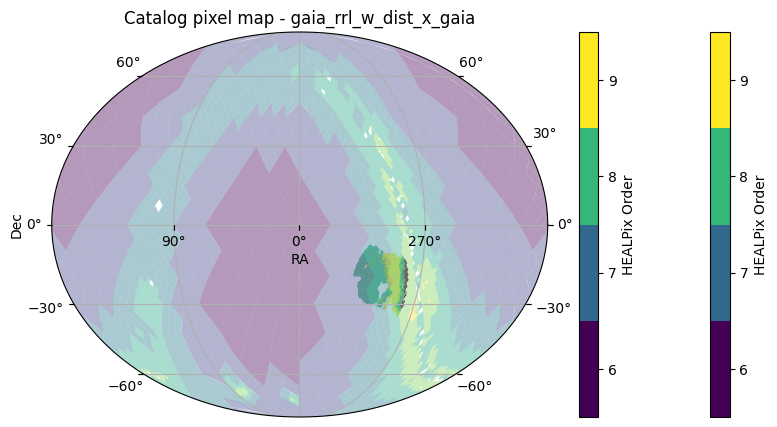

In [22]:
dp2_fitted.plot_pixels()
li_gaia.plot_pixels(alpha=0.4)

In [24]:
li_gaia.columns

Index(['Gaia_gaia_rrl_w_dist', 'ra_gaia_rrl_w_dist', 'dec_gaia_rrl_w_dist',
       '[Fe/H]_gaia_rrl_w_dist', 'e_[Fe/H]_gaia_rrl_w_dist',
       'MGmag_gaia_rrl_w_dist', 'e_MGmag_gaia_rrl_w_dist',
       'EBV_gaia_rrl_w_dist', 'r_EBV_gaia_rrl_w_dist',
       'Dist_Phot_gaia_rrl_w_dist', 'e_Dist_Phot_gaia_rrl_w_dist',
       'Type_gaia_rrl_w_dist', 'solution_id_gaia', 'designation_gaia',
       'source_id_gaia', 'ref_epoch_gaia', 'ra_gaia', 'ra_error_gaia',
       'dec_gaia', 'dec_error_gaia', 'parallax_gaia', 'parallax_error_gaia',
       'pm_gaia', 'pmra_gaia', 'pmra_error_gaia', 'pmdec_gaia',
       'pmdec_error_gaia', 'phot_g_n_obs_gaia', 'phot_g_mean_flux_gaia',
       'phot_g_mean_flux_error_gaia', 'phot_g_mean_mag_gaia',
       'phot_bp_n_obs_gaia', 'phot_bp_mean_flux_gaia',
       'phot_bp_mean_flux_error_gaia', 'phot_bp_mean_mag_gaia',
       'phot_rp_n_obs_gaia', 'phot_rp_mean_flux_gaia',
       'phot_rp_mean_flux_error_gaia', 'phot_rp_mean_mag_gaia',
       '_dist_arcsec'],
  

In [25]:
dp2_fitted.columns

Index(['objectId', 'coord_dec', 'coord_ra', 'u_psfMag', 'u_psfMagErr',
       'g_psfMag', 'g_psfMagErr', 'r_psfMag', 'r_psfMagErr', 'i_psfMag',
       'i_psfMagErr', 'z_psfMag', 'z_psfMagErr', 'y_psfMag', 'y_psfMagErr',
       'ebv', 'u_psfMagExt', 'g_psfMagExt', 'r_psfMagExt', 'i_psfMagExt',
       'z_psfMagExt', 'y_psfMagExt', 'n_lc', 'std', 'wrms', 'p_est', 'p_err',
       'wrms_ratio', 'mu', 'd', 'a', 'phi', 'chi2_u', 'flat_chi2_u', 'wrms_u',
       'offset_u', 'chi2_g', 'flat_chi2_g', 'wrms_g', 'offset_g', 'chi2_r',
       'flat_chi2_r', 'wrms_r', 'offset_r', 'chi2_i', 'flat_chi2_i', 'wrms_i',
       'offset_i', 'chi2_z', 'flat_chi2_z', 'wrms_z', 'offset_z', 'chi2_y',
       'flat_chi2_y', 'wrms_y', 'offset_y', 'chi2_total', 'flat_chi2_total'],
      dtype='object')

In [ ]:
# Getting bizarre column duplication errors even though the columns do not overlap, need suffixes like this
comparison_catalog = li_gaia.crossmatch(dp2_fitted, suffixes=("_","_dp2")) # inner match
comparison_catalog

/astro/store/epyc/users/brantd/lsdb/src/lsdb/catalog/catalog.py:387: FutureWarning: The default suffix behavior will change from applying suffixes to all columns to only applying suffixes to overlapping columns in a future release.To maintain the current behavior, explicitly set `suffix_method='all_columns'`. To change to the new behavior, set `suffix_method='overlapping_columns'`.
  warnings.warn(


,Gaia_gaia_rrl_w_dist_,ra_gaia_rrl_w_dist_,dec_gaia_rrl_w_dist_,[Fe/H]_gaia_rrl_w_dist_,e_[Fe/H]_gaia_rrl_w_dist_,MGmag_gaia_rrl_w_dist_,e_MGmag_gaia_rrl_w_dist_,EBV_gaia_rrl_w_dist_,r_EBV_gaia_rrl_w_dist_,Dist_Phot_gaia_rrl_w_dist_,e_Dist_Phot_gaia_rrl_w_dist_,Type_gaia_rrl_w_dist_,solution_id_gaia_,designation_gaia_,source_id_gaia_,ref_epoch_gaia_,ra_gaia_,ra_error_gaia_,dec_gaia_,dec_error_gaia_,parallax_gaia_,parallax_error_gaia_,pm_gaia_,pmra_gaia_,pmra_error_gaia_,pmdec_gaia_,pmdec_error_gaia_,phot_g_n_obs_gaia_,phot_g_mean_flux_gaia_,phot_g_mean_flux_error_gaia_,phot_g_mean_mag_gaia_,phot_bp_n_obs_gaia_,phot_bp_mean_flux_gaia_,phot_bp_mean_flux_error_gaia_,phot_bp_mean_mag_gaia_,phot_rp_n_obs_gaia_,phot_rp_mean_flux_gaia_,phot_rp_mean_flux_error_gaia_,phot_rp_mean_mag_gaia_,_dist_arcsec_,objectId_dp2,coord_dec_dp2,coord_ra_dp2,u_psfMag_dp2,u_psfMagErr_dp2,g_psfMag_dp2,g_psfMagErr_dp2,r_psfMag_dp2,r_psfMagErr_dp2,i_psfMag_dp2,i_psfMagErr_dp2,z_psfMag_dp2,z_psfMagErr_dp2,y_psfMag_dp2,y_psfMagErr_dp2,ebv_dp2,u_psfMagExt_dp2,g_psfMagExt_dp2,r_psfMagExt_dp2,i_psfMagExt_dp2,z_psfMagExt_dp2,y_psfMagExt_dp2,n_lc_dp2,std_dp2,wrms_dp2,p_est_dp2,p_err_dp2,wrms_ratio_dp2,mu_dp2,d_dp2,a_dp2,phi_dp2,chi2_u_dp2,flat_chi2_u_dp2,wrms_u_dp2,offset_u_dp2,chi2_g_dp2,flat_chi2_g_dp2,wrms_g_dp2,offset_g_dp2,chi2_r_dp2,flat_chi2_r_dp2,wrms_r_dp2,offset_r_dp2,chi2_i_dp2,flat_chi2_i_dp2,wrms_i_dp2,offset_i_dp2,chi2_z_dp2,flat_chi2_z_dp2,wrms_z_dp2,offset_z_dp2,chi2_y_dp2,flat_chi2_y_dp2,wrms_y_dp2,offset_y_dp2,chi2_total_dp2,flat_chi2_total_dp2,_dist_arcsec
npartitions=7158,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 6, Pixel: 28753",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],string[pyarrow],double[pyarrow],double[pyarrow],string[pyarrow],int64[pyarrow],string[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],int32[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow]
"Order: 6, Pixel: 28755",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [36]:
comparison_catalog.write_catalog("../dp2_gaia_comp_medium", overwrite=True)

## 2. Analyze Comparison Catalog

In [41]:
comp = lsdb.open_catalog("../dp2_gaia_comp_medium")
comp_df = comp.compute()

In [42]:
comp_df

,Gaia_gaia_rrl_w_dist_,ra_gaia_rrl_w_dist_,dec_gaia_rrl_w_dist_,[Fe/H]_gaia_rrl_w_dist_,e_[Fe/H]_gaia_rrl_w_dist_,MGmag_gaia_rrl_w_dist_,e_MGmag_gaia_rrl_w_dist_,EBV_gaia_rrl_w_dist_,r_EBV_gaia_rrl_w_dist_,Dist_Phot_gaia_rrl_w_dist_,e_Dist_Phot_gaia_rrl_w_dist_,Type_gaia_rrl_w_dist_,solution_id_gaia_,designation_gaia_,source_id_gaia_,ref_epoch_gaia_,ra_gaia_,ra_error_gaia_,dec_gaia_,dec_error_gaia_,parallax_gaia_,parallax_error_gaia_,pm_gaia_,pmra_gaia_,pmra_error_gaia_,pmdec_gaia_,pmdec_error_gaia_,phot_g_n_obs_gaia_,phot_g_mean_flux_gaia_,phot_g_mean_flux_error_gaia_,phot_g_mean_mag_gaia_,phot_bp_n_obs_gaia_,phot_bp_mean_flux_gaia_,phot_bp_mean_flux_error_gaia_,phot_bp_mean_mag_gaia_,phot_rp_n_obs_gaia_,phot_rp_mean_flux_gaia_,phot_rp_mean_flux_error_gaia_,phot_rp_mean_mag_gaia_,_dist_arcsec_,objectId_dp2,coord_dec_dp2,coord_ra_dp2,u_psfMag_dp2,u_psfMagErr_dp2,g_psfMag_dp2,g_psfMagErr_dp2,r_psfMag_dp2,r_psfMagErr_dp2,i_psfMag_dp2,i_psfMagErr_dp2,z_psfMag_dp2,z_psfMagErr_dp2,y_psfMag_dp2,y_psfMagErr_dp2,ebv_dp2,u_psfMagExt_dp2,g_psfMagExt_dp2,r_psfMagExt_dp2,i_psfMagExt_dp2,z_psfMagExt_dp2,y_psfMagExt_dp2,n_lc_dp2,std_dp2,wrms_dp2,p_est_dp2,p_err_dp2,wrms_ratio_dp2,mu_dp2,d_dp2,a_dp2,phi_dp2,chi2_u_dp2,flat_chi2_u_dp2,wrms_u_dp2,offset_u_dp2,chi2_g_dp2,flat_chi2_g_dp2,wrms_g_dp2,offset_g_dp2,chi2_r_dp2,flat_chi2_r_dp2,wrms_r_dp2,offset_r_dp2,chi2_i_dp2,flat_chi2_i_dp2,wrms_i_dp2,offset_i_dp2,chi2_z_dp2,flat_chi2_z_dp2,wrms_z_dp2,offset_z_dp2,chi2_y_dp2,flat_chi2_y_dp2,wrms_y_dp2,offset_y_dp2,chi2_total_dp2,flat_chi2_total_dp2,_dist_arcsec
_healpix_29,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2035927755365142091,4071855496008516224,283.054825,-28.152466,-1.87,0.33,0.45,0.13,0.23,c22,26.23,2.54,RRab,1636148068921376768,Gaia DR3 4071855496008516224,4071855496008516224,2016.0,283.054825,0.133676,-28.152466,0.12604,0.385856,0.163403,2.957627,-2.531304,0.170299,-1.529723,0.135771,194,1069.95812,14.472233,18.11395,21,539.722239,27.928062,18.508116,21,750.105537,26.13585,17.56009,0.000064,756325049127936206,-28.152469,283.054818,19.670277,0.006591,18.58622,0.001157,18.091593,0.001138,18.013309,0.003414,17.811584,0.001768,17.797623,0.002742,0.26171,18.425265,17.628213,17.384618,17.475846,17.39544,17.455383,32,0.23535,0.286422,0.706159,0.000199,1.856347,17.409016,0.0,0.773421,0.55073,<NA>,<NA>,<NA>,<NA>,409.856195,92.219467,0.452952,0.41152,154.914212,69.430496,0.341048,0.238069,86.853137,41.640957,0.228745,0.110478,109.501027,44.716236,0.234563,0.0,133.267762,25.796286,0.217739,-0.080248,40.654197,10.952138,0.027381
2035932405007481927,4071864807494759040,283.229546,-27.927904,-1.68,0.46,0.52,0.17,0.59,c22,18.31,2.09,RRab,1636148068921376768,Gaia DR3 4071864807494759040,4071864807494759040,2016.0,283.229546,0.157085,-27.927904,0.154415,-0.197554,0.17901,3.067848,-2.550494,0.204598,-1.704896,0.165018,194,923.526718,13.021421,18.273743,20,624.316925,43.469994,18.350029,19,768.611864,22.855183,17.533628,0.000068,756325667603233797,-27.92791,283.229541,20.088699,0.008366,18.683983,0.001143,18.161427,0.00114,18.142809,0.003944,18.024374,0.002723,17.840622,0.003428,0.265515,18.825584,17.712046,17.444172,17.59753,17.602179,17.493406,38,0.271875,0.213504,0.602007,0.000629,1.487293,17.403896,0.0,0.589884,0.15632,<NA>,<NA>,<NA>,<NA>,424.399168,147.632111,0.426716,0.550522,223.513895,108.537674,0.309622,0.22029,65.128353,32.753956,0.180726,0.084519,16.965483,10.245909,0.08556,0.0,25.736462,10.396023,0.094277,-0.199435,26.990834,9.985989,0.027658
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3453258835061284197,6906517663504433664,310.065569,-

In [40]:
len(comp)

1026

In [38]:
comp.columns

Index(['Gaia_gaia_rrl_w_dist_', 'ra_gaia_rrl_w_dist_', 'dec_gaia_rrl_w_dist_',
       '[Fe/H]_gaia_rrl_w_dist_', 'e_[Fe/H]_gaia_rrl_w_dist_',
       'MGmag_gaia_rrl_w_dist_', 'e_MGmag_gaia_rrl_w_dist_',
       'EBV_gaia_rrl_w_dist_', 'r_EBV_gaia_rrl_w_dist_',
       'Dist_Phot_gaia_rrl_w_dist_', 'e_Dist_Phot_gaia_rrl_w_dist_',
       'Type_gaia_rrl_w_dist_', 'solution_id_gaia_', 'designation_gaia_',
       'source_id_gaia_', 'ref_epoch_gaia_', 'ra_gaia_', 'ra_error_gaia_',
       'dec_gaia_', 'dec_error_gaia_', 'parallax_gaia_',
       'parallax_error_gaia_', 'pm_gaia_', 'pmra_gaia_', 'pmra_error_gaia_',
       'pmdec_gaia_', 'pmdec_error_gaia_', 'phot_g_n_obs_gaia_',
       'phot_g_mean_flux_gaia_', 'phot_g_mean_flux_error_gaia_',
       'phot_g_mean_mag_gaia_', 'phot_bp_n_obs_gaia_',
       'phot_bp_mean_flux_gaia_', 'phot_bp_mean_flux_error_gaia_',
       'phot_bp_mean_mag_gaia_', 'phot_rp_n_obs_gaia_',
       'phot_rp_mean_flux_gaia_', 'phot_rp_mean_flux_error_gaia_',
       'phot_

### 2.1 p_est (pipeline) vs. Li+22 period 

In [53]:
period_df = comp_df[["EBV_gaia_rrl_w_dist_","p_est_dp2", "p_err_dp2"]]
period_df

,EBV_gaia_rrl_w_dist_,p_est_dp2,p_err_dp2
_healpix_29,,,
2035927755365142091,0.23,0.706159,0.000199
2035932405007481927,0.59,0.602007,0.000629
...,...,...,...
3453258835061284197,0.04,0.39823,0.113188
3453327397860174535,0.05,0.598404,0.000008


(array([  48.,  159.,  954., 2397., 2251.,  573.,  253.,   91.,   44.,
         204.]),
 array([0.30985654, 0.37885588, 0.44785523, 0.51685458, 0.58585392,
        0.65485327, 0.72385261, 0.79285196, 0.86185131, 0.93085065,
        0.99985   ]),
 <BarContainer object of 10 artists>)

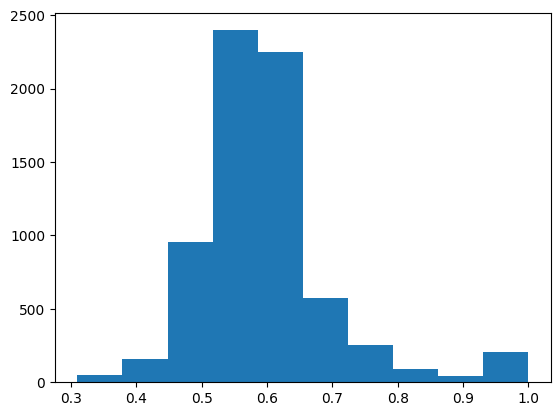

In [58]:
import pandas as pd
des_df = pd.read_csv("/astro/store/epyc/data/des_rrl/des_rrab_catalog.csv")
plt.hist(des_df["PERIOD_0"])

(array([ 25., 141.,  74.,  30., 145., 281., 225.,  63.,  34.,   8.]),
 array([0.20035619, 0.26872921, 0.33710224, 0.40547527, 0.47384829,
        0.54222132, 0.61059434, 0.67896737, 0.74734039, 0.81571342,
        0.88408644]),
 <BarContainer object of 10 artists>)

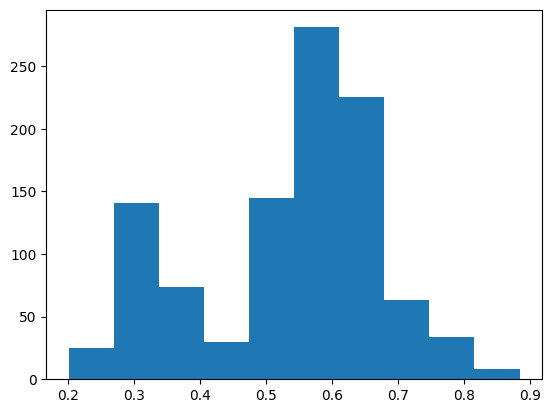

In [62]:
plt.hist(period_df["p_est_dp2"])


### 2.2 Compare Distances

mu from fit_coeffs is a proxy for distance — compare directly to Gaia parallax-derived distances or PL-based distances in Li+22


In [45]:
distance_df = comp_df[['Dist_Phot_gaia_rrl_w_dist_','e_Dist_Phot_gaia_rrl_w_dist_',"mu_dp2"]]
distance_df["delta"] = distance_df["mu_dp2"] - distance_df["Dist_Phot_gaia_rrl_w_dist_"]
distance_df

,Dist_Phot_gaia_rrl_w_dist_,e_Dist_Phot_gaia_rrl_w_dist_,mu_dp2,delta
_healpix_29,,,,
2035927755365142091,26.23,2.54,17.409016,-8.820984
2035932405007481927,18.31,2.09,17.403896,-0.906104
...,...,...,...,...
3453258835061284197,10.6,1.09,14.86096,4.26096
3453327397860174535,17.93,1.67,16.283396,-1.646604


In [48]:
# Find fraction within 1 sigma
within_1sigma = np.abs(distance_df["delta"]) < distance_df["e_Dist_Phot_gaia_rrl_w_dist_"]
fraction_within_1sigma = np.mean(within_1sigma)
print(f"Fraction of stars with distance agreement within 1 sigma: {fraction_within_1sigma:.2f}")

Fraction of stars with distance agreement within 1 sigma: 0.14


(array([  1.,   0.,   0.,   4.,   8.,  15.,  37., 274., 272., 415.]),
 array([-73.24090445, -65.06325457, -56.88560469, -48.70795482,
        -40.53030494, -32.35265506, -24.17500519, -15.99735531,
         -7.81970543,   0.35794444,   8.53559432]),
 <BarContainer object of 10 artists>)

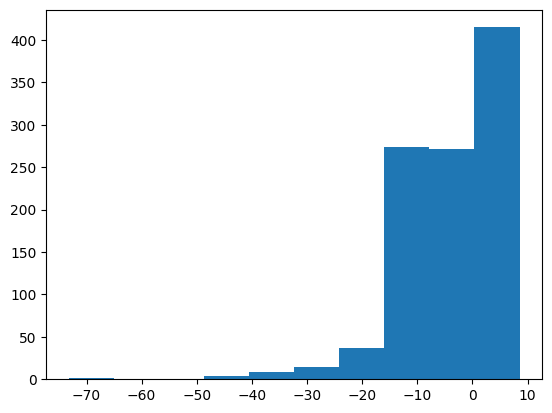

In [47]:
plt.hist(distance_df["delta"])

### 2.3 Check for Systematic Offsets

Per-band Δm offsets from fit_coeffs encode color — compare to Li+22 mean magnitudes per band to check for systematic photometric offsets between DP2 and GaiA.

In [51]:
dp2_offset_columns = [f"offset_{band}_dp2" for band in ["u","g","r","i","z","y"]]
mean_li_mags=['phot_g_mean_mag_gaia_']

comp_df[dp2_offset_columns+mean_li_mags]

,offset_u_dp2,offset_g_dp2,offset_r_dp2,offset_i_dp2,offset_z_dp2,offset_y_dp2,phot_g_mean_mag_gaia_
_healpix_29,,,,,,,
2035927755365142091,<NA>,0.41152,0.238069,0.110478,0.0,-0.080248,18.11395
2035932405007481927,<NA>,0.550522,0.22029,0.084519,0.0,-0.199435,18.273743
...,...,...,...,...,...,...,...
3453258835061284197,<NA>,<NA>,0.131839,0.035382,0.0,-0.184828,15.564348
3453327397860174535,<NA>,0.116197,0.088225,0.033864,<NA>,0.0,16.86246
